# Step 1 - Define the problem

# Step 2 - Collect and Prepare Data(EDA)

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot

In [2]:
titanic_test=pd.read_csv('Titanic_test.csv')
titanic_train=pd.read_csv('Titanic_train.csv')

## Step 2.1 - Understand the Dataset                                                      

## EDA for test data

### Step 2.1.1 Use .head(), .tail(), .info(), and .shape() to get a feel for it.    

In [3]:
titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print('test ',titanic_test.shape)
print('train ',titanic_train.shape)

test  (418, 11)
train  (891, 12)


In [6]:
print('train null sum \n',titanic_train.isnull().sum())

train null sum 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
print('test null sum \n',titanic_test.isnull().sum())


test null sum 
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [8]:
titanic_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


- Pclass - need to convert into object datatype


In [9]:
titanic_test['Pclass']=titanic_test['Pclass'].astype('object')
titanic_train['Pclass']=titanic_train['Pclass'].astype('object')

In [10]:
titanic_train.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200


### Step 2.1.2 check the distinct values in each column                   

In [11]:
titanic_train['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [12]:
titanic_train['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [13]:
titanic_train['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [14]:
titanic_train['Fare'].value_counts()

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64

In [15]:
titanic_train['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [16]:
titanic_train['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [17]:
titanic_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [18]:
titanic_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### Step 2.1.3 Check data types: numerical, categorical, datetime,remove unwanted columns and rows, remove duplicate rows, convert the datatype etc.

In [19]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
- With the help of domain knowledge we can remove Name,SibSp,Parch,Ticket,Cabin

SyntaxError: invalid syntax (1038462700.py, line 1)

In [21]:
titanic_train[['Survived','Pclass','Sex','Age','Fare','Cabin','Embarked']]

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked
0,0,3,male,22.0,7.2500,NaN,S
1,1,1,female,38.0,71.2833,C85,C
2,1,3,female,26.0,7.9250,NaN,S
3,1,1,female,35.0,53.1000,C123,S
4,0,3,male,35.0,8.0500,NaN,S
...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,NaN,S
887,1,1,female,19.0,30.0000,B42,S
888,0,3,female,NaN,23.4500,NaN,S
889,1,1,male,26.0,30.0000,C148,C


In [22]:
titanic_train1=titanic_train[['Survived','Pclass','Sex','Age','Fare','Embarked']].copy()
titanic_test1=titanic_test[['Pclass','Sex','Age','Fare','Embarked']].copy()

In [23]:
titanic_train1.head()
titanic_test1.head()

,Pclass,Sex,Age,Fare,Embarked
0,3,male,34.5,7.8292,Q
1,3,female,47.0,7.0000,S
2,2,male,62.0,9.6875,Q
3,3,male,27.0,8.6625,S
4,3,female,22.0,12.2875,S


##  Step 2.3 - Analyze Target Variable – decide the target variable

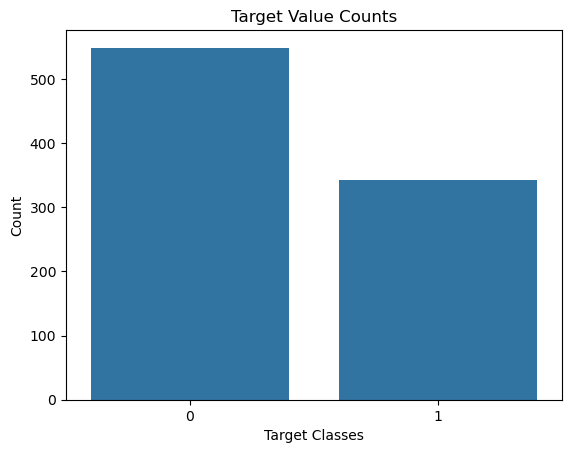

In [24]:
sns.countplot(x='Survived', data=titanic_train1)
plt.title('Target Value Counts')
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.show()

In [25]:
titanic_train[['Survived',]].value_counts()

Survived
0           549
1           342
Name: count, dtype: int64

In [26]:
- The datase is imbalanced 

SyntaxError: invalid syntax (2423755379.py, line 1)

In [27]:
titanic_train[['Survived','Sex']].value_counts()

Survived  Sex   
0         male      468
1         female    233
          male      109
0         female     81
Name: count, dtype: int64

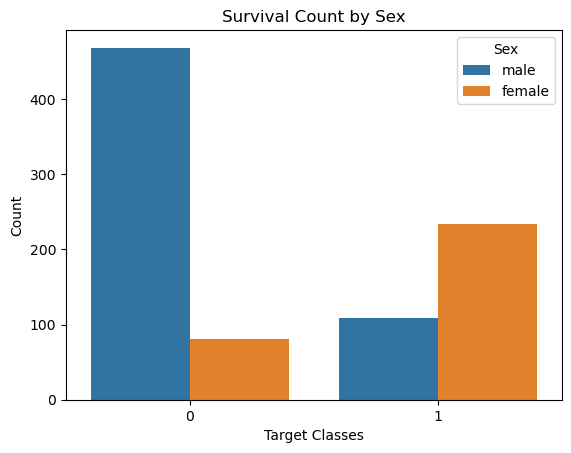

In [28]:
sns.countplot(x='Survived',hue='Sex', data=titanic_train1)
plt.title('Survival Count by Sex')
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

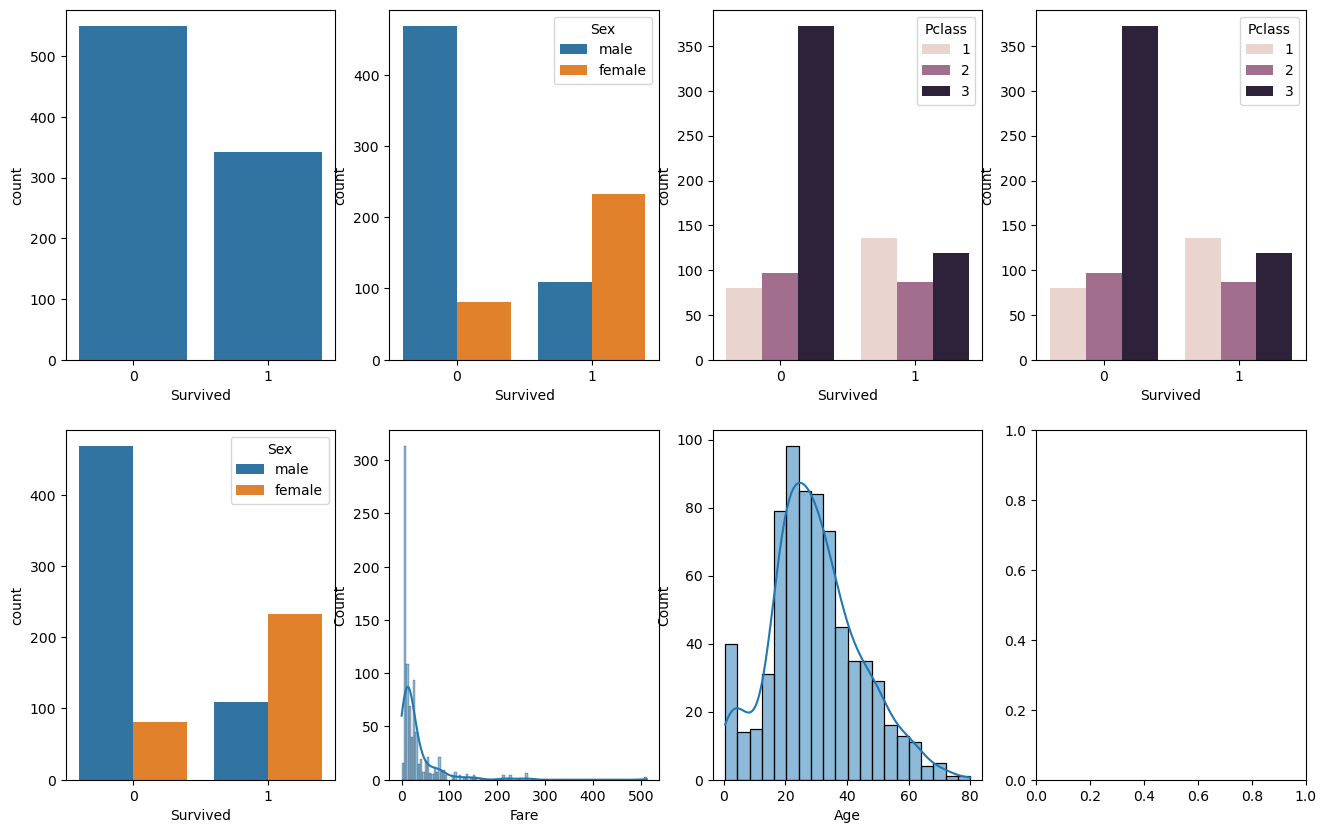

In [199]:
fig, axes = plt.subplots(2,4, figsize=(16, 10))
sns.countplot(x='Survived', data=titanic_train1,ax=axes[0,0])
sns.countplot(x='Survived',hue='Sex', data=titanic_train1,ax=axes[0,1])
sns.countplot(x='Survived',hue='Pclass', data=titanic_train1,ax=axes[0,2])
sns.countplot(x='Survived',hue='Pclass', data=titanic_train1,ax=axes[0,3])
sns.countplot(x='Survived',hue='Sex', data=titanic_train1,ax=axes[1,0])

sns.histplot(x='Fare', data=titanic_train1,kde=True, ax=axes[1,1])
sns.histplot(x='Age', data=titanic_train1,kde=True, ax=axes[1,2])

In [30]:
#titanic_train[['Survived','Pclass']].value_counts().sort_values(by='Pclass',ascending=True)
titanic_train1[['Survived', 'Pclass']].value_counts().reset_index(name='Count').sort_values(by='Pclass', ascending=True)


,Survived,Pclass,Count
1,1,1,136
5,0,1,80
4,1,2,87
3,0,2,97
2,1,3,119
0,0,3,372


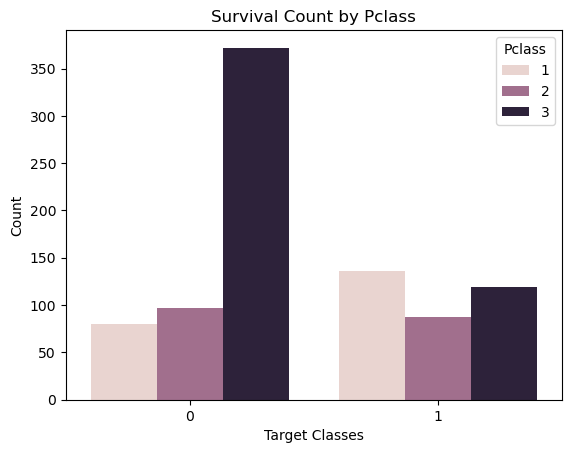

In [31]:
sns.countplot(x='Survived',hue='Pclass', data=titanic_train1)
plt.title('Survival Count by Pclass')
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.show()

In [32]:
titanic_test[].isnull().sum()

SyntaxError: invalid syntax (3723644901.py, line 1)

## Step 2.4 - Univariate Analysis (Single Variable) 

In [ ]:
titanic_train1.head()

#### Age varuiable

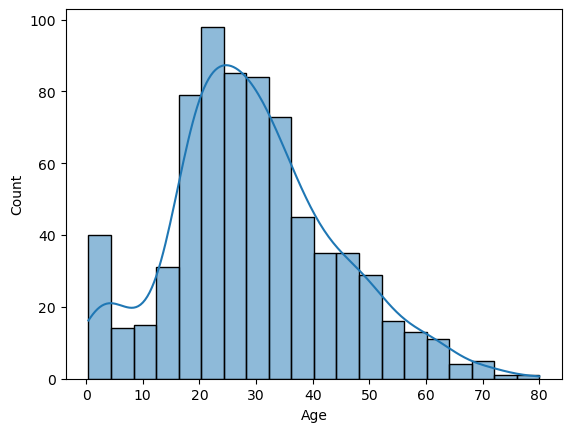

In [33]:
sns.histplot(data=titanic_train1,x='Age',kde=True)
plt.show()

In [34]:
- Right skewed data, may be there are some outliers

SyntaxError: invalid syntax (1680379654.py, line 1)

<Figure size 300x300 with 0 Axes>

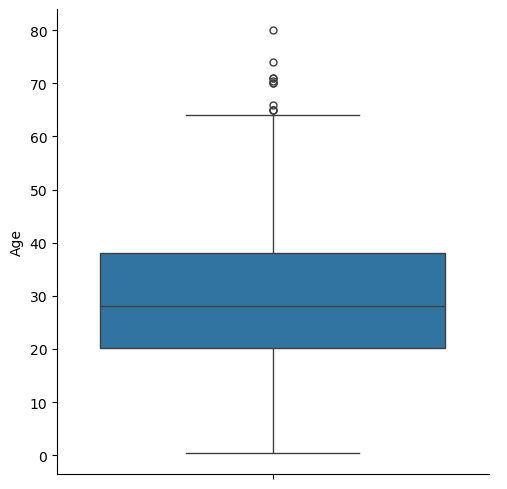

"plt.figure(figsize=(3,3))\nsns.catplot(toyota_df_enc,y='Age_08_04',kind='box')\nplt.show()"

In [35]:
plt.figure(figsize=(3,3))
sns.catplot(titanic_train1,y='Age',kind='box')
plt.show()

'''plt.figure(figsize=(3,3))
sns.catplot(toyota_df_enc,y='Age_08_04',kind='box')
plt.show()'''

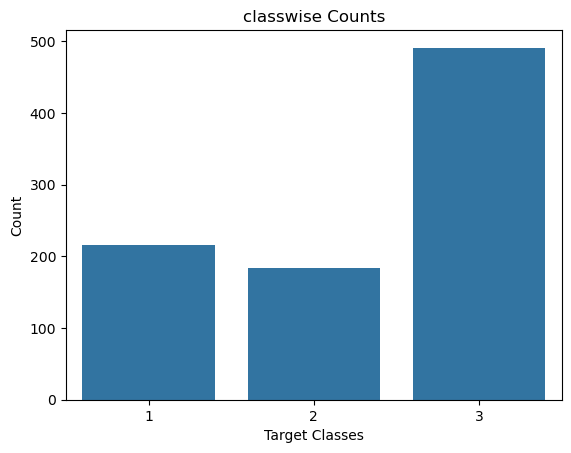

In [36]:
sns.countplot(x='Pclass', data=titanic_train1)
plt.title('classwise Counts')
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.show()

## Step 2.5 - Check for Missing Values – Find out how many and where

In [37]:
titanic_train1.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

- Filling null values for Age variable

In [38]:
age_mean_Train=titanic_train1['Age'].mean()

In [39]:
titanic_train1_notnull=titanic_train1.copy()

In [40]:
np.round(titanic_train1['Age'].mean(),1)

np.float64(29.7)

In [41]:
titanic_train1_notnull['Age']=titanic_train1['Age'].fillna(np.round(titanic_train1['Age'].mean(),1))

In [42]:
titanic_train1_notnull.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
Embarked    2
dtype: int64

- Filling null values for Embarked variable

In [43]:
titanic_train1_notnull['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [44]:
titanic_train1_notnull['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [45]:
titanic_train1_notnull['Embarked']=titanic_train1_notnull['Embarked'].fillna(titanic_train1_notnull['Embarked'].mode()[0])

In [46]:
titanic_train1_notnull.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

##  Step 2.6 - Bivariate/Multivariate Analysis

In [47]:
titanic_train1_notnull.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    object 
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   Fare      891 non-null    float64
 5   Embarked  891 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 41.9+ KB


In [48]:
titanic_train1_notnull.describe(include=['object'])

,Pclass,Sex,Embarked
count,891,891,891
unique,3,2,3
top,3,male,S
freq,491,577,646


In [49]:
titanic_train1_notnull.describe(include=['int'])

,Survived
count,891.000000
mean,0.383838
std,0.486592
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [50]:
titanic_train1_notnull_numeric=titanic_train1_notnull.select_dtypes(include=['int','float'])

In [51]:
titanic_train1_notnull_numeric.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [52]:
titanic_train1_notnull_numeric.corr()

,Survived,Age,Fare
Survived,1.000000,-0.069811,0.257307
Age,-0.069811,1.000000,0.091563
Fare,0.257307,0.091563,1.000000


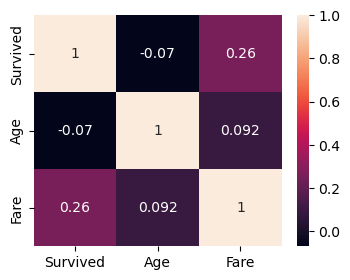

In [53]:
plt.figure(figsize=(4,3))
sns.heatmap(titanic_train1_notnull_numeric.corr(),annot=True)
plt.show()

## Step 2.7 – Encoding the values

In [54]:
titanic_train1_notnull_Enc = pd.get_dummies(titanic_train1_notnull, columns=['Sex', 'Embarked', 'Pclass'],dtype=int, drop_first=True)
# drop_first - drops first feature from encoded values
# dtype=int - this will return the output in 0,1 or else by default it will return True,False

In [55]:
titanic_train1_notnull_Enc.head()

,Survived,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,1,0,1
1,1,38.0,71.2833,0,0,0,0,0
2,1,26.0,7.9250,0,0,1,0,1
3,1,35.0,53.1000,0,0,1,0,0
4,0,35.0,8.0500,1,0,1,0,1


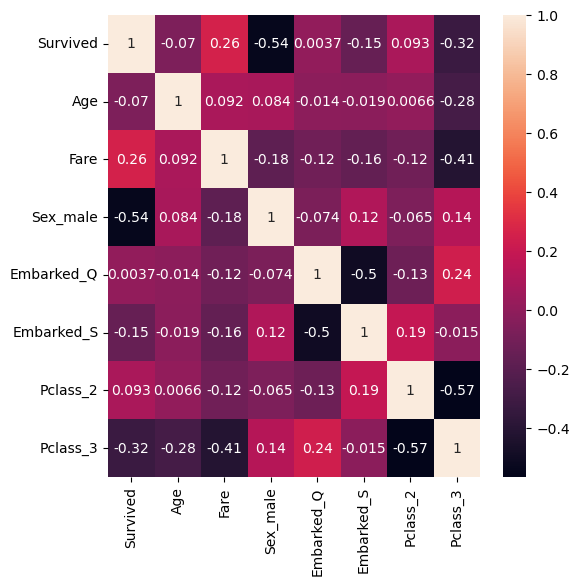

In [56]:
plt.figure(figsize=(6,6))
sns.heatmap(titanic_train1_notnull_Enc.corr(),annot=True)
plt.show()

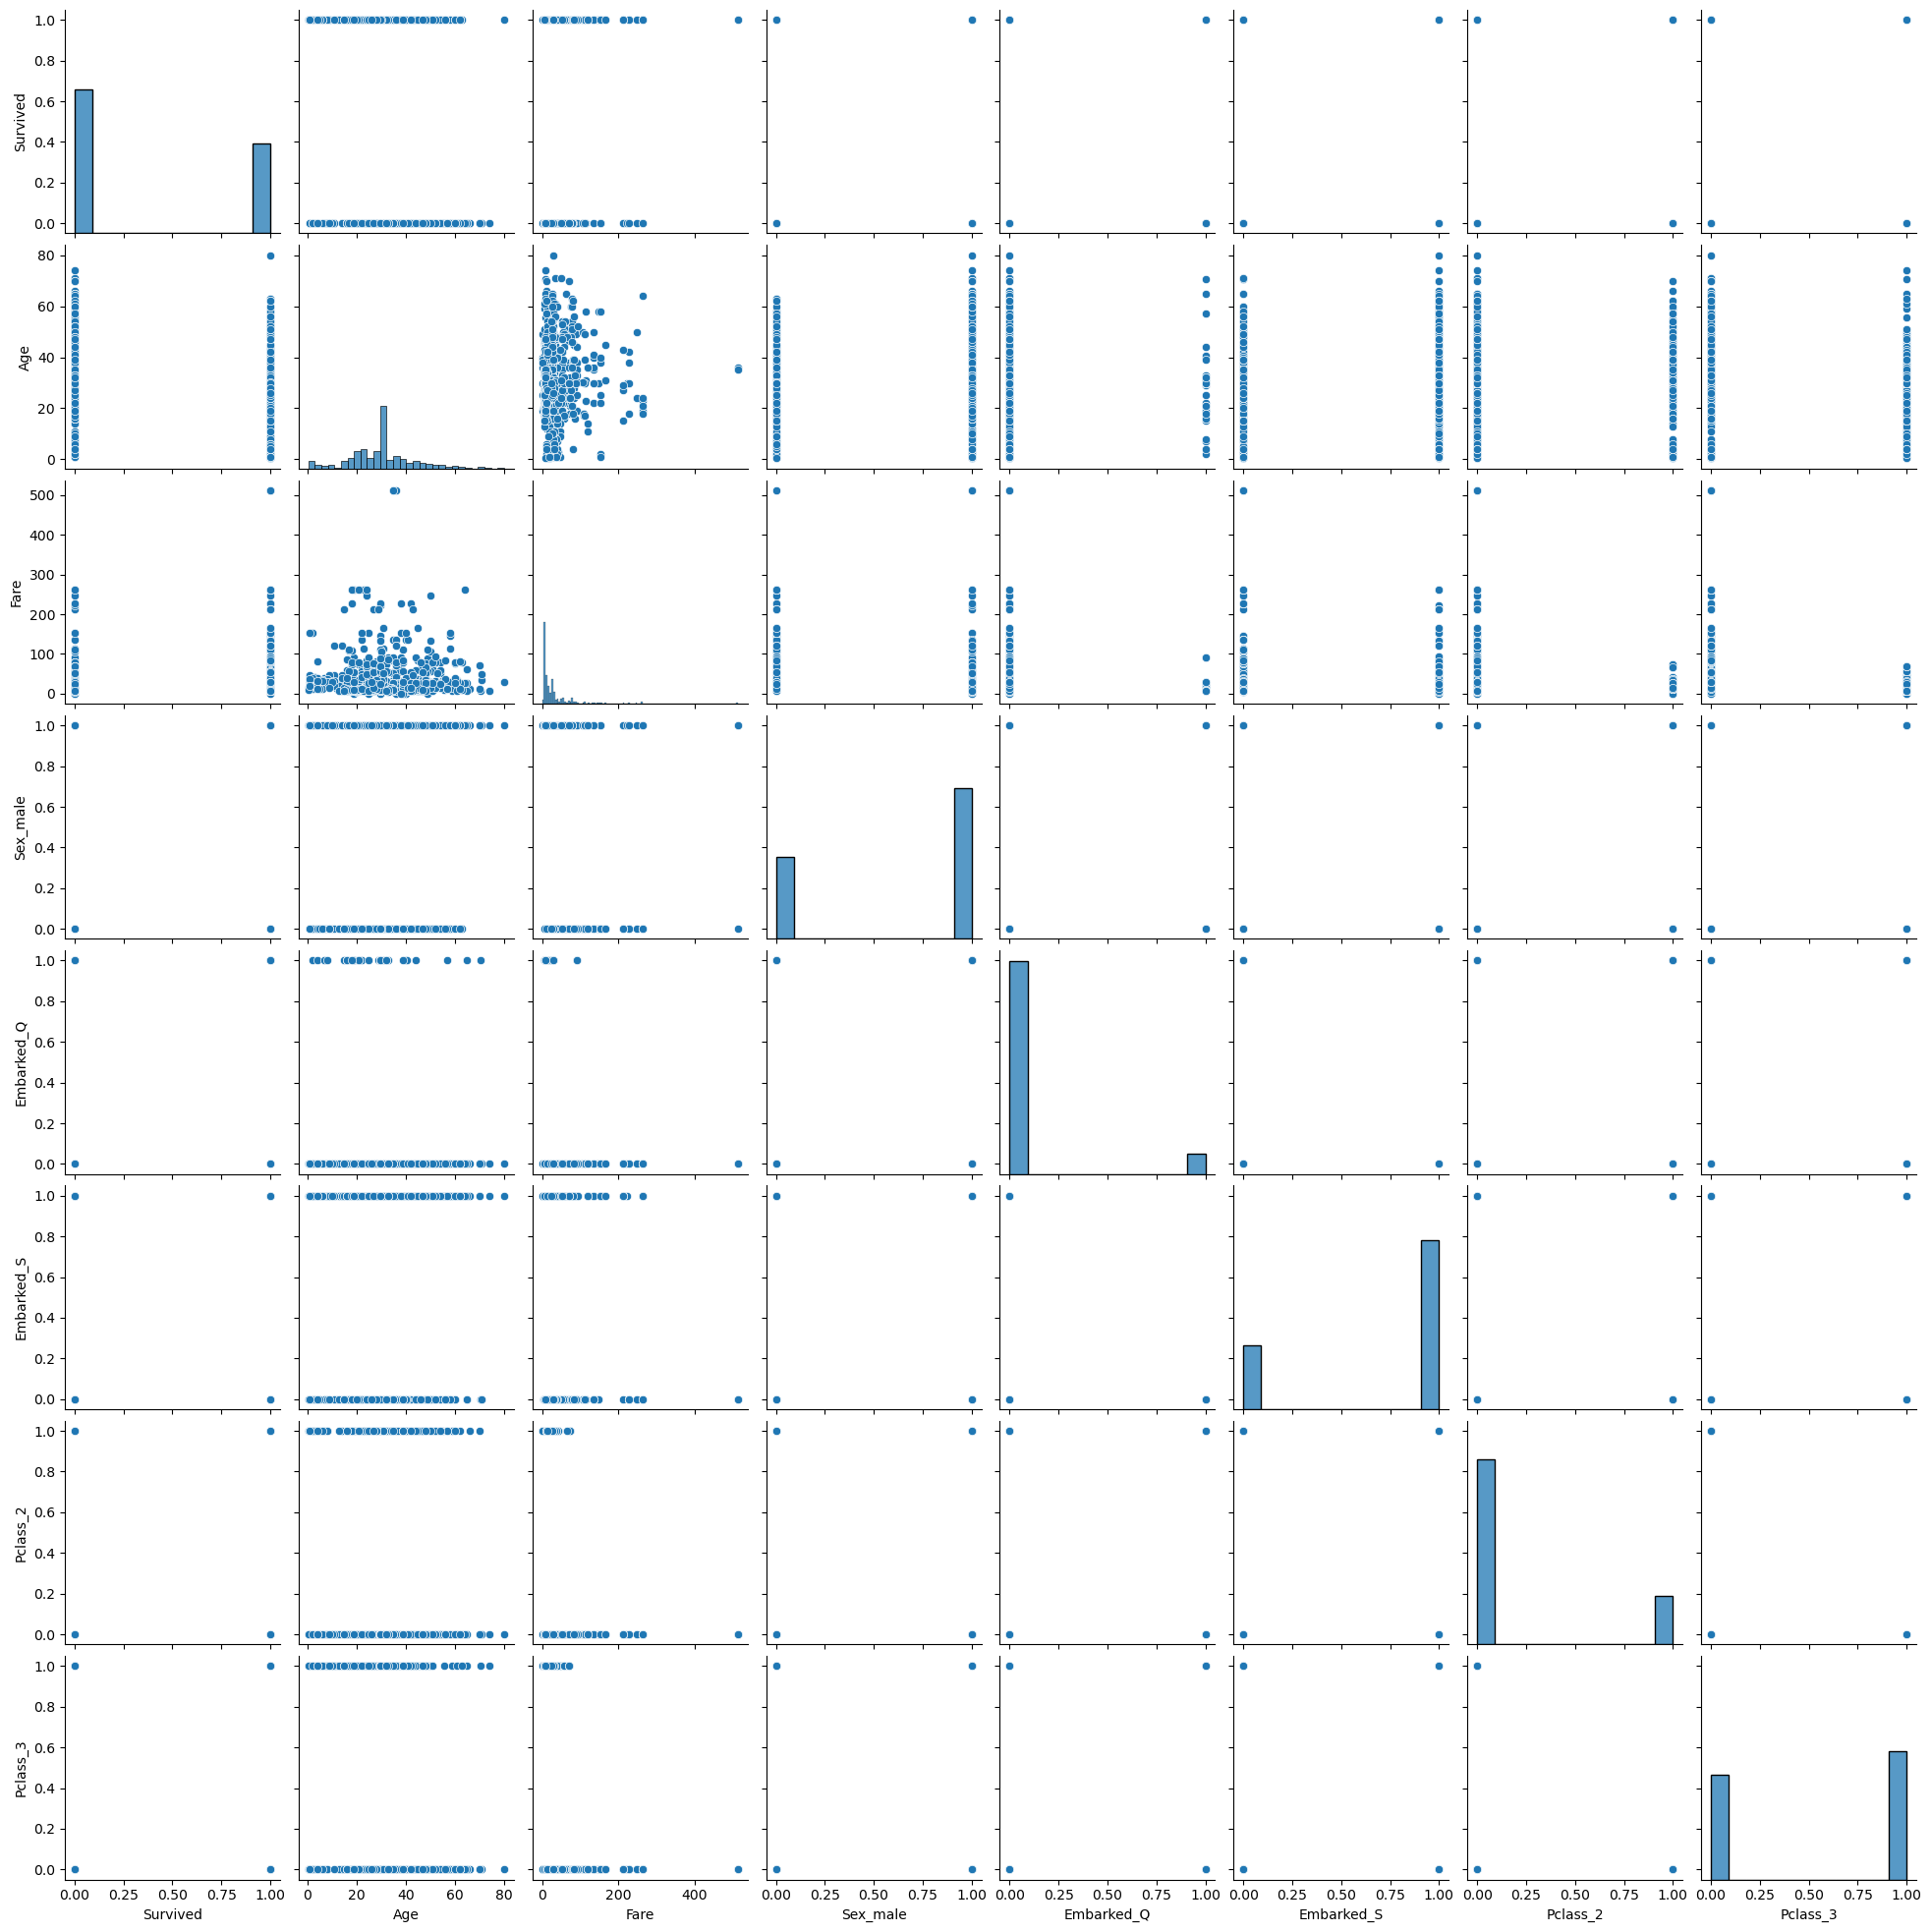

In [57]:
sns.pairplot(titanic_train1_notnull_Enc)

##  Step 2.8 - Outlier Detection

In [58]:
plt.figure(figsize=(6,6))

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Axes: xlabel='Survived', ylabel='count'>

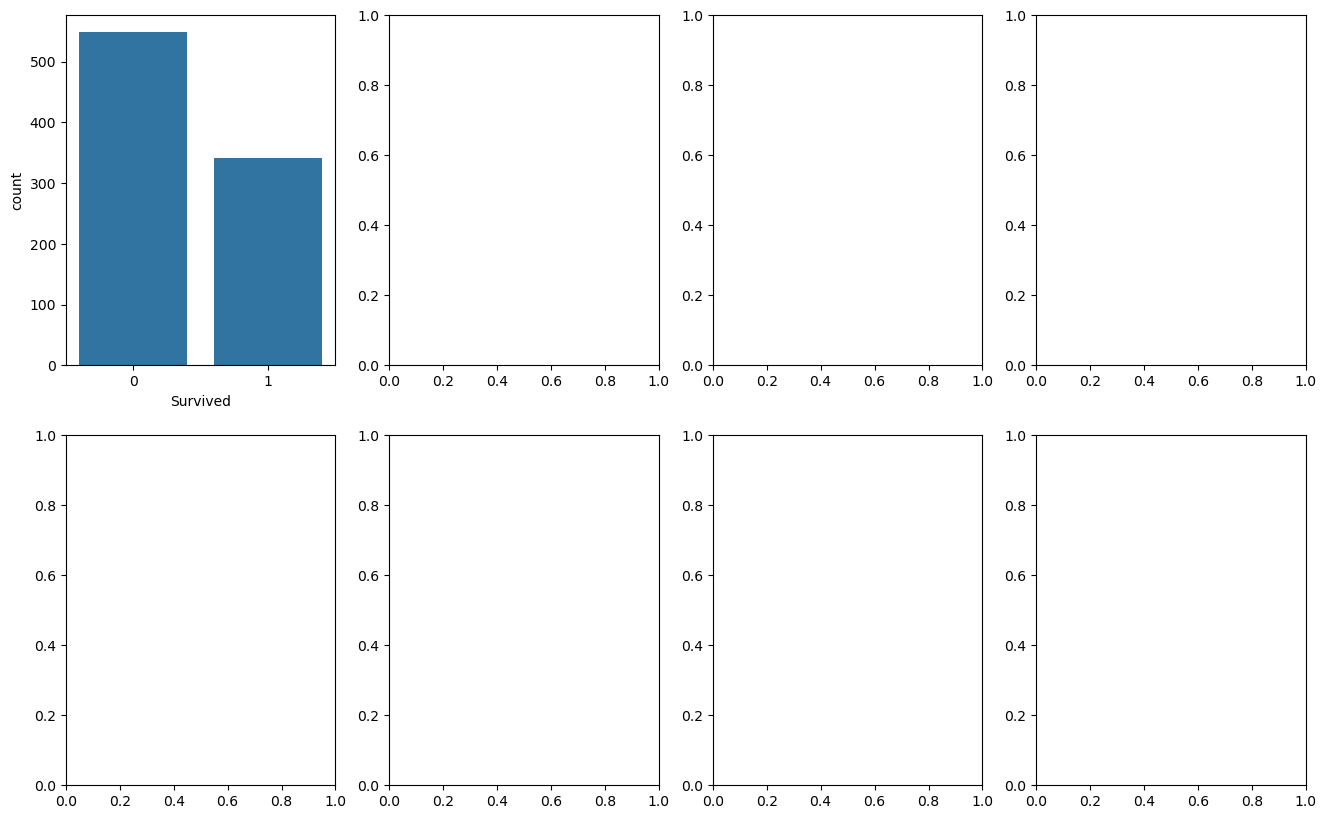

In [59]:
fig, axes = plt.subplots(2,4, figsize=(16, 10))
sns.countplot(x='Survived', data=titanic_train1,ax=axes[0,0])

<Figure size 600x600 with 0 Axes>

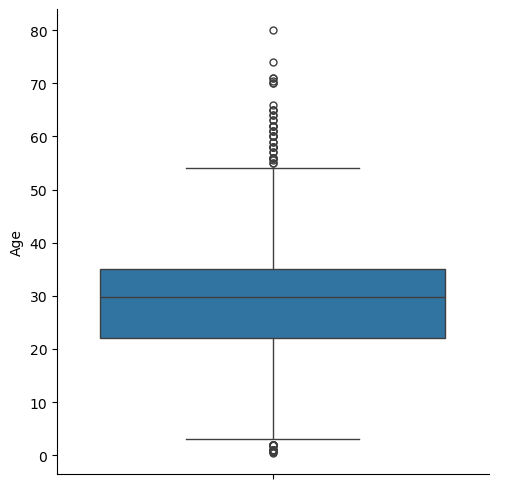

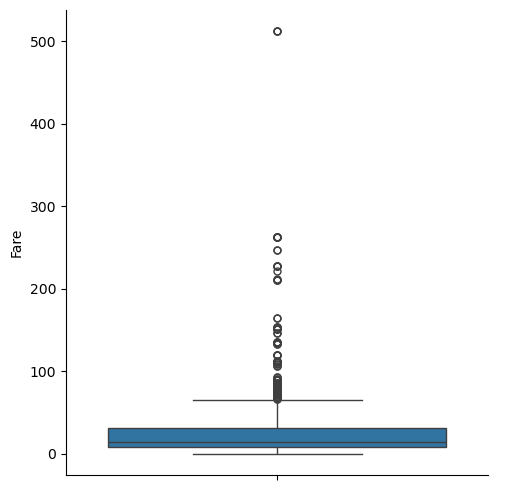

In [60]:
plt.figure(figsize=(6,6))
sns.catplot(titanic_train1_notnull_Enc,y='Age',kind='box')
sns.catplot(titanic_train1_notnull_Enc,y='Fare',kind='box')
plt.show()

- These features are showing the outlier in figure but these are not actual outlier. these expected value as high class can have high fare.

##  Step 2.11 – Feature selection 

### 2.12.5) Variance Threshold

In [61]:
titanic_train1_notnull_Enc.head()

,Survived,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,1,0,1
1,1,38.0,71.2833,0,0,0,0,0
2,1,26.0,7.9250,0,0,1,0,1
3,1,35.0,53.1000,0,0,1,0,0
4,0,35.0,8.0500,1,0,1,0,1


In [62]:
# titanic_train1_notnull_Enc.select_dtypes(include=[np.number])

In [63]:
from sklearn.feature_selection import VarianceThreshold
mdlsel = VarianceThreshold(threshold=0.5)
mdlsel.fit(titanic_train1_notnull_Enc)
imp_features = mdlsel.get_support()
print(imp_features)


[False  True  True False False False False False]


In [64]:
#titanic_train1_notnull_Enc.columns.values[imp_features]

In [65]:
#data1 = mdlsel.transform(train) 
imp_features_df = pd.DataFrame(mdlsel.transform(titanic_train1_notnull_Enc), columns = titanic_train1_notnull_Enc.columns.values[imp_features])
imp_features_df.head() 

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [66]:
print(mdlsel.variances_) # to check the variance of each feature

[2.36506479e-01 1.68862667e+02 2.46666531e+03 2.28218083e-01
 7.89513794e-02 1.99362373e-01 1.63863350e-01 2.47392241e-01]


### 2.12.6) Select K base

# Step 3 - Split the Data

##  Step 3.1 - find out independent and dependent variable

##  Step 3.2 split the data into X-train and Y-train

In [74]:
x_train=titanic_train1_notnull_Enc.iloc[:,1:]

In [145]:
x_train.head()

,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,22.0,7.2500,1,0,1,0,1
1,38.0,71.2833,0,0,0,0,0
2,26.0,7.9250,0,0,1,0,1
3,35.0,53.1000,0,0,1,0,0
4,35.0,8.0500,1,0,1,0,1


In [146]:
y_train=titanic_train1_notnull_Enc.iloc[:,:1]

In [147]:
y_train.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [148]:
x_train.shape,y_train.shape,

((891, 7), (891, 1))

In [149]:
titanic_train1_notnull_Enc.head()

,Survived,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,1,0,1
1,1,38.0,71.2833,0,0,0,0,0
2,1,26.0,7.9250,0,0,1,0,1
3,1,35.0,53.1000,0,0,1,0,0
4,0,35.0,8.0500,1,0,1,0,1


### 3.2.2 Scale the dataset – if required

In [150]:
from sklearn.preprocessing import StandardScaler

In [151]:
stdsclr=StandardScaler()
x_train_scaled=stdsclr.fit_transform(x_train)

In [152]:
display(x_train_scaled)

array([[-5.92494088e-01, -5.02445171e-01,  7.37695132e-01, ...,
         6.15838425e-01, -5.10151543e-01,  9.02587365e-01],
       [ 6.38775523e-01,  7.86845294e-01, -1.35557354e+00, ...,
        -1.62380254e+00, -5.10151543e-01, -1.10792599e+00],
       [-2.84676685e-01, -4.88854258e-01, -1.35557354e+00, ...,
         6.15838425e-01, -5.10151543e-01,  9.02587365e-01],
       ...,
       [ 5.44121672e-05, -1.76263239e-01, -1.35557354e+00, ...,
         6.15838425e-01, -5.10151543e-01,  9.02587365e-01],
       [-2.84676685e-01, -4.43810379e-02,  7.37695132e-01, ...,
        -1.62380254e+00, -5.10151543e-01, -1.10792599e+00],
       [ 1.77049419e-01, -4.92377828e-01,  7.37695132e-01, ...,
        -1.62380254e+00, -5.10151543e-01,  9.02587365e-01]])

# Step 5 - Choose the Algorithm and Build the model


# Step 6 -Train the Model

In [153]:
from sklearn.linear_model import LogisticRegression

In [154]:
logreg=LogisticRegression()
model_titanic=logreg.fit(x_train_scaled,y_train)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [155]:
y_hat_train=model_titanic.predict(x_train_scaled) # while predicting y_hat_TRain need to pass scaled data
#print(y_hat_train)

In [156]:
y_hat_train

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,

## Step 6.2 - Check the measure for x_train data and evaluate the       

### Step 6.2.1 Evaluate model using confusion_matrix,classification_report

In [157]:
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve

In [158]:
cm_metrics=confusion_matrix(y_train,y_hat_train)
print(cm_metrics)

[[463  86]
 [101 241]]


In [159]:
cls_report=classification_report(y_train,y_hat_train)
print(cls_report)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       549
           1       0.74      0.70      0.72       342

    accuracy                           0.79       891
   macro avg       0.78      0.77      0.78       891
weighted avg       0.79      0.79      0.79       891



- model has descent balance between precision and call

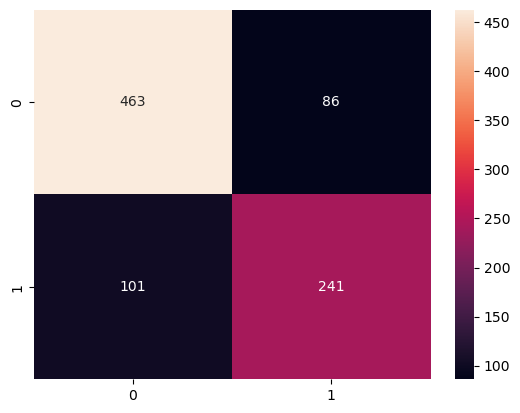

In [160]:
sns.heatmap(cm_metrics,annot=True,fmt='d')
plt.show()

### Step 6.2.2 Evaluate model using AOC ROC curve

In [161]:
def plot_roc(y,yhat):
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve')
    plt.xlabel('False positive Rate(FPR)')
    plt.ylabel('True positive Rate(TPR)')

    fpr,tpr,thresh=roc_curve(y,yhat)  # by default threshold will 50%
   # auc=roc_auc_score(y,yhat)
   # auc
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1],'o--')
    plt.show()

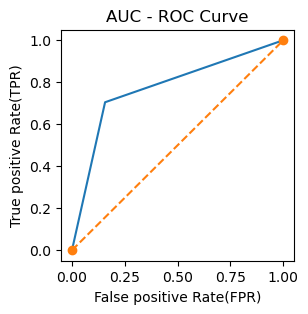

In [162]:
plot_roc(y_train,y_hat_train)

In [163]:
auc_score=roc_auc_score(y_train,y_hat_train)
print(auc_score)

0.7740149554213402


In [164]:
- The AUC score is 77%

SyntaxError: invalid syntax (3277574831.py, line 1)

## Step 6.2 - Check the measure for x_test data and evaluate the       

In [165]:
titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [166]:
titanic_test1_notnull=titanic_test1.copy()
titanic_test1_notnull.isnull().sum()

Pclass       0
Sex          0
Age         86
Fare         1
Embarked     0
dtype: int64

In [167]:
titanic_test1_notnull['Age']=titanic_test1_notnull['Age'].fillna(np.round(titanic_test1['Age'].mean(),1))
titanic_test1_notnull['Embarked']=titanic_train1_notnull['Embarked'].fillna(titanic_test1['Embarked'].mode()[0])
titanic_test1_notnull['Fare']=titanic_test1_notnull['Fare'].fillna(np.round(titanic_test1['Fare'].mean(),1))


In [168]:
titanic_test1_notnull.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

In [169]:
titanic_test1_notnull_Enc = pd.get_dummies(titanic_test1_notnull, columns=['Sex', 'Embarked', 'Pclass'],dtype=int, drop_first=True)


In [170]:
titanic_test1_notnull_Enc.head()

,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,34.5,7.8292,1,0,1,0,1
1,47.0,7.0000,0,0,0,0,1
2,62.0,9.6875,1,0,1,1,0
3,27.0,8.6625,1,0,1,0,1
4,22.0,12.2875,0,0,1,0,1


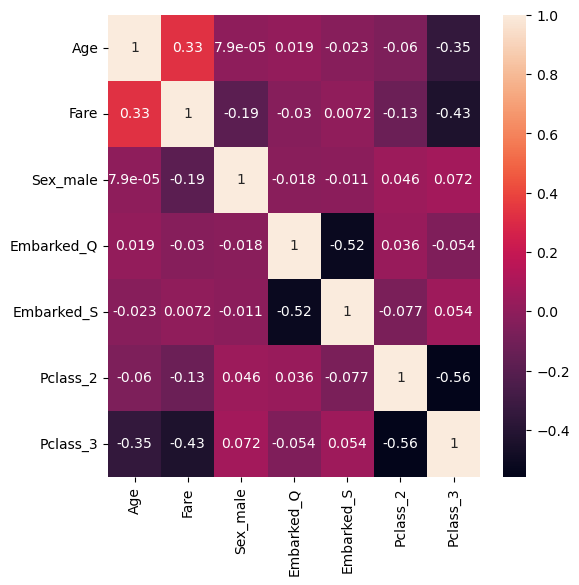

In [171]:
plt.figure(figsize=(6,6))
sns.heatmap(titanic_test1_notnull_Enc.corr(),annot=True)
plt.show()

In [172]:
x_test=titanic_test1_notnull_Enc.iloc[:,:]

In [173]:
x_test.shape

(418, 7)

In [174]:
x_test.head()

,Age,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,34.5,7.8292,1,0,1,0,1
1,47.0,7.0000,0,0,0,0,1
2,62.0,9.6875,1,0,1,1,0
3,27.0,8.6625,1,0,1,0,1
4,22.0,12.2875,0,0,1,0,1


In [175]:
#logreg_test=LogisticRegression()
#model_titanic_test=logreg.fit(x_test_scaled) # no need to train and fit the test data seperately as the model is already trained, we can use same model for prediction 

In [185]:

x_test_scaled=stdsclr.transform(x_test) # no need fit again, alreay fitted while scaling the training data. use same model to scale test data

In [186]:
x_test_scaled

array([[ 0.3694353 , -0.49078316,  0.73769513, ...,  0.61583843,
        -0.51015154,  0.90258736],
       [ 1.33136468, -0.50747884, -1.35557354, ..., -1.62380254,
        -0.51015154,  0.90258736],
       [ 2.48567994, -0.45336687,  0.73769513, ...,  0.61583843,
         1.96020185, -1.10792599],
       ...,
       [ 0.6772527 , -0.50244517,  0.73769513, ...,  0.61583843,
        -0.51015154,  0.90258736],
       [ 0.04622702, -0.48633742,  0.73769513, ...,  0.61583843,
        -0.51015154,  0.90258736],
       [ 0.04622702, -0.19824428,  0.73769513, ...,  0.61583843,
        -0.51015154,  0.90258736]])

In [187]:
y_hat_test=model_titanic.predict(x_test_scaled) # while predicting y_hat_TRain need to pass scaled data


In [188]:
y_hat_test

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [189]:
print("Coefficients:", model_titanic.coef_)
print("Intercept:", model_titanic.intercept_)


Coefficients: [[-0.41951464  0.01845717 -1.21562798  0.00190713 -0.24189309 -0.36827684
  -1.10363431]]
Intercept: [-0.65387531]


In [195]:
coefficients = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model_titanic.coef_[0],
    "Intercept" : model_titanic.intercept_[0]
})

In [196]:
coefficients

,Feature,Coefficient,Intercept
0,Age,-0.419515,-0.653875
1,Fare,0.018457,-0.653875
2,Sex_male,-1.215628,-0.653875
3,Embarked_Q,0.001907,-0.653875
4,Embarked_S,-0.241893,-0.653875
5,Pclass_2,-0.368277,-0.653875
6,Pclass_3,-1.103634,-0.653875


- Analysis
- Test data
- Descirbe method -  by using this method we have analyszed below points
- SibSp - has some outliers
- Parch - has some outliers
- Fare - has some outliers(may be these are valid as there is classwise fair)
- Casuality rate is more than survival
- Servival rate of female is more than male
- casuality rate of class 3 is high, may be because they might have got stuck into basement
- Feature selection
- Variance Threshold - with this method we found only 2 feature Age,Fare
- On the training dataset model has given 79% accuracy whihc is not bad

- Coeffecient analysis
-  Sex_male :  -1.25 with highest nehgative coefficient, means male category has the very less chance of servival
-  Age : -0.49 after the male criteria age is one of the major criteria which has very less chance of servival
-  Fare : is the one of the criteria which shows high vervial rate. As the fare is high then it is very high chance of servival

# What is the difference between precision and recall?

In [ ]:
- Precision known as a positive predictive value, is defined as the fraction of relevant
    instances among the retrieved instances.
    Precision = TP/TP+FP
    Where TP is true positive
    FP id False Positive

- Recall, also known as sensitivity, is defined as the fraction of relevant instances that were
    Retrieved.
    Recall = TP/TP+FP.
    Where TP is true positive
    FP is False positive.

# What is cross-validation, and why is it important in binary classification?

In [ ]:
- Cross validation it is technique in which we split the training the dataset into multiple set, so model can learn on all possible combination/variation of data.
- Ex- kfold validation, stratified fold validation, hold validation
- Binary classifcation often has imbalanced data, so rather than relying on fixed train test data it makes the different combination of datasets to train the model.
    by using this we can avoid overfitting